In [ ]:
# 배열 및 수식 연산을 위한 NumPy 라이브러리 불러오기
import numpy as np


# 코너 좌표 형식(xyxy)을 중심점 및 크기 형식(xywh)으로 변환하는 함수
def xyxy_to_xywh(x1, y1, x2, y2):
    """[x1,y1,x2,y2] -> [cx,cy,w,h]"""
    # 바운딩 박스의 중심 x 좌표(cx) 계산
    cx = (x1 + x2) / 2
    # 바운딩 박스의 중심 y 좌표(cy) 계산
    cy = (y1 + y2) / 2
    # 바운딩 박스의 너비(w) 계산
    w = x2 - x1
    # 바운딩 박스의 높이(h) 계산
    h = y2 - y1
    # 중심 좌표 및 너비, 높이 반환
    return cx, cy, w, h


# 중심점 및 크기 형식(xywh)을 코너 좌표 형식(xyxy)으로 변환하는 함수
def xywh_to_xyxy(cx, cy, w, h):
    """[cx,cy,w,h] -> [x1,y1,x2,y2]"""
    # 좌상단 x 좌표(x1) 계산
    x1 = cx - w / 2
    # 좌상단 y 좌표(y1) 계산
    y1 = cy - h / 2
    # 우하단 x 좌표(x2) 계산
    x2 = cx + w / 2
    # 우하단 y 좌표(y2) 계산
    y2 = cy + h / 2
    # 좌상단 및 우하단 코너 좌표 반환
    return x1, y1, x2, y2


# 픽셀 단위의 코너 좌표를 이미지 크기 대비 비율(0~1 사이값)인
# YOLO 정규화 형식으로 변환하는 함수
def normalize_bbox(x1, y1, x2, y2, img_w, img_h):
    """픽셀 좌표 -> YOLO 정규화 형식 (0~1)"""
    # 픽셀 단위 코너 좌표를 중심점과 너비·높이로 변환
    cx, cy, w, h = xyxy_to_xywh(x1, y1, x2, y2)
    # 이미지 너비와 높이로 각각 나누어 0~1 사이의 정규화된 값 반환
    return cx / img_w, cy / img_h, w / img_w, h / img_h


# --- 예제 실행 --------------------
# 기준이 될 이미지의 너비(640px)와 높이(480px) 설정
img_w, img_h = 640, 480

# 픽셀 단위의 객체 바운딩 박스 좌표 (좌상단: 100, 150 / 우하단: 300, 350) 설정
x1, y1, x2, y2 = 100, 150, 300, 350

# 픽셀 좌표를 YOLO 정규화 포맷(cx, cy, w, h 비율)으로 변환
cx, cy, w, h = normalize_bbox(x1, y1, x2, y2, img_w, img_h)

# 변환된 YOLO 형식의 결과값 출력 (소수점 4자리까지 표시)
print(f"YOLO 형식: cx={cx:.4f}, cy={cy:.4f}, w={w:.4f}, h={h:.4f}")
# YOLO 형식: cx=0.3125, cy=0.5208, w=0.3125, h=0.4167

YOLO 형식: cx=0.3125, cy=0.5208, w=0.3125, h=0.4167


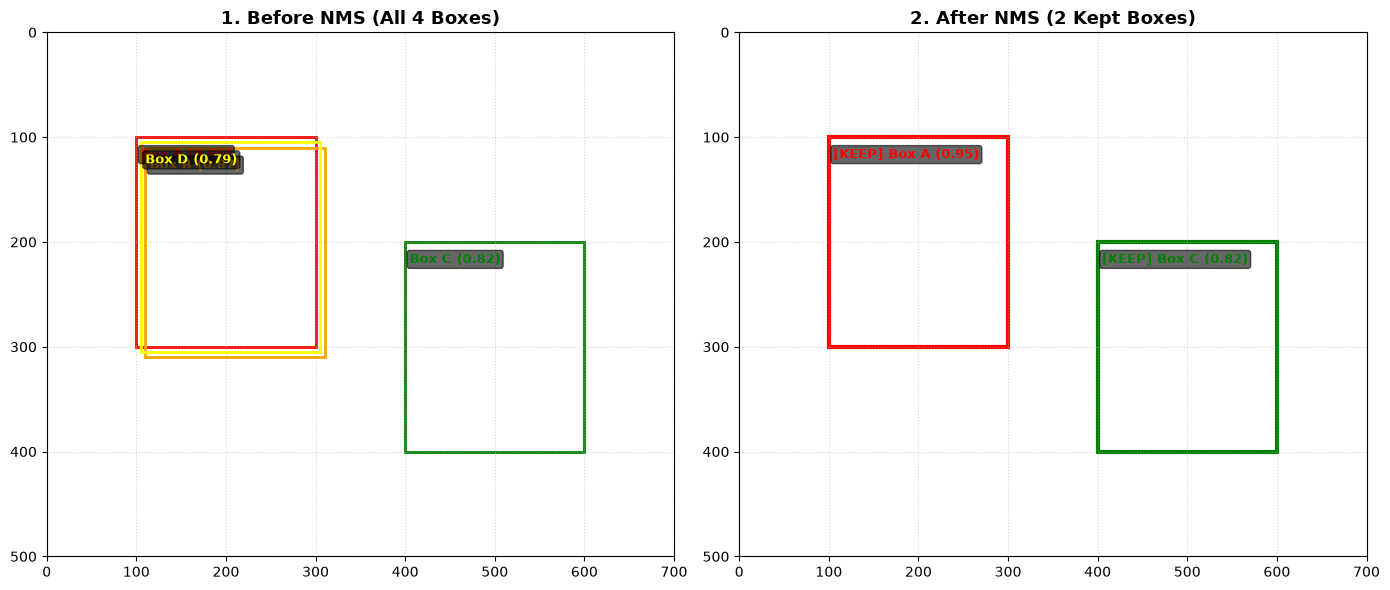

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# ==========================================
# 1. IoU (Intersection over Union) 계산 함수
# ==========================================
def compute_iou(box1, box2):
    """
    두 바운딩 박스 간의 IoU(교집합 넓이 / 합집합 넓이)를 계산하는 함수입니다.
    
    Parameters:
        box1, box2: [x1, y1, x2, y2] 형식의 바운딩 박스 좌표
                    (x1, y1): 좌상단 좌표, (x2, y2): 우하단 좌표
    Returns:
        float: 0.0 ~ 1.0 사이의 IoU 값
    """
    # 1-1. 두 박스가 중첩(교집합)되는 영역의 좌상단(ix1, iy1) 및 우하단(ix2, iy2) 좌표 구하기
    ix1 = max(box1[0], box2[0])  # 교집합 좌상단 x : 두 박스의 x1 중 더 큰 값
    iy1 = max(box1[1], box2[1])  # 교집합 좌상단 y : 두 박스의 y1 중 더 큰 값
    ix2 = min(box1[2], box2[2])  # 교집합 우하단 x : 두 박스의 x2 중 더 작은 값
    iy2 = min(box1[3], box2[3])  # 교집합 우하단 y : 두 박스의 y2 중 더 작은 값

    # 1-2. 교집합 영역의 너비(inter_w)와 높이(inter_h) 계산
    # 박스가 서로 겹치지 않으면 (ix2 - ix1)이 음수가 되므로 max(0, ...)를 사용하여 0으로 처리
    inter_w = max(0, ix2 - ix1)
    inter_h = max(0, iy2 - iy1)
    intersection = inter_w * inter_h  # 교집합 넓이

    # 1-3. 두 박스 각각의 넓이 및 전체 합집합(Union) 넓이 계산
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])  # 첫 번째 박스 전체 넓이
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])  # 두 번째 박스 전체 넓이
    
    # 합집합 넓이 = (박스1 넓이) + (박스2 넓이) - (중복된 교집합 넓이)
    union = area1 + area2 - intersection

    # 1-4. IoU 계산 (교집합 넓이 / 합집합 넓이)
    # 0으로 나누는 계산 오류(ZeroDivisionError)를 방지하기 위해 분모에 1e-8(아주 작은 값)을 더함
    return intersection / (union + 1e-8)


# ==========================================
# 2. NMS (Non-Maximum Suppression) 함수
# ==========================================
def nms(boxes, scores, iou_threshold=0.45):
    """
    중복으로 생성된 바운딩 박스를 제거하고 가장 신뢰도가 높은 박스만 남기는 함수입니다.
    
    Parameters:
        boxes: 바운딩 박스 목록 [[x1, y1, x2, y2], ...]
        scores: 각 박스에 대한 예측 신뢰도 점수 목록 [score1, score2, ...]
        iou_threshold: 중복으로 간주하여 제거할 IoU 임계값 (기본값: 0.45)
    Returns:
        list: 최종 선택(Keep)된 박스들의 인덱스 목록
    """
    # 2-1. 검사할 박스가 없는 경우 빈 리스트 반환
    if len(boxes) == 0:
        return []

    # 2-2. 신뢰도 점수(scores)를 기준 내림차순(높은 점수 -> 낮은 점수)으로 정렬했을 때의 원본 인덱스 추출
    # np.argsort는 오름차순이므로 [::-1]을 붙여 내림차순으로 뒤집음
    order = np.argsort(scores)[::-1]
    
    # 최종적으로 남겨둘 박스들의 인덱스를 담을 리스트
    keep = []

    # 2-3. 처리할 박스가 인덱스 배열(order)에 남아있는 동안 반복 수행
    while len(order) > 0:
        # 남아있는 박스 중 신뢰도 점수가 가장 높은 박스의 인덱스 선택
        best = order[0]
        keep.append(best)  # 해당 박스는 최종 채택 리스트에 추가

        # 남은 박스가 1개뿐이었다면 추가 비교 없이 반복 종료
        if len(order) == 1:
            break

        # 2-4. 현재 최고 점수 박스(best)와 나머지 박스들(order[1:]) 간의 IoU 일괄 계산
        ious = np.array(
            [compute_iou(boxes[best], boxes[i]) for i in order[1:]]
        )

        # 2-5. IoU가 임계값(iou_threshold) 미만인 박스만 남김
        # 즉, IoU >= iou_threshold인 '중복률이 높은 박스'들은 필터링되어 자동으로 제거됨
        order = order[1:][ious < iou_threshold]

    # 최종 선택된 박스 인덱스 목록 반환
    return keep


# ==========================================
# 3. 테스트 데이터 설정 및 NMS 실행
# ==========================================
# 테스트용 바운딩 박스 좌표 4개 [x1, y1, x2, y2]
test_boxes = [
    [100, 100, 300, 300],  # 박스 A (인덱스 0)
    [110, 110, 310, 310],  # 박스 B (인덱스 1) - 박스 A와 높은 중복도
    [400, 200, 600, 400],  # 박스 C (인덱스 2) - 독립적인 위치
    [105, 105, 305, 305],  # 박스 D (인덱스 3) - 박스 A와 높은 중복도
]

# 각 박스별 신뢰도 점수 (A, B, C, D 순서)
test_scores = [0.95, 0.87, 0.82, 0.79]

# 박스 시각화 시 구별을 위해 지정한 4가지 색상 및 라벨
box_colors = ['red', 'orange', 'green', 'yellow']
box_labels = ['Box A (0.95)', 'Box B (0.87)', 'Box C (0.82)', 'Box D (0.79)']

# IoU 임계값 0.5로 설정하여 NMS 실행
kept_idx = nms(test_boxes, test_scores, iou_threshold=0.5)


# ==========================================
# 4. Matplotlib을 활용한 시각화 (NMS 전/후 비교)
# ==========================================
# 1행 2열 구조의 서브플롯(그래프 화면) 생성
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# ------------------------------------------
# [왼쪽 화면] NMS 적용 전: 4개 전체 박스 표시
# ------------------------------------------
ax1.set_xlim(0, 700)
ax1.set_ylim(500, 0)  # 이미지 좌표계 기준(위쪽이 y=0, 아래로 갈수록 y 증가)에 맞춰 y축 반전
ax1.set_title("1. Before NMS (All 4 Boxes)", fontsize=13, fontweight='bold')

# 4개의 입력 박스를 반복문으로 순회하며 그려줌
for i, (box, score) in enumerate(zip(test_boxes, test_scores)):
    x1, y1, x2, y2 = box
    width, height = x2 - x1, y2 - y1  # 박스의 너비와 높이 계산
    color = box_colors[i]             # 해당 박스에 지정된 색상 추출

    # 사각형 도형 객체 생성 (배경은 투명, 테두리는 지정 색상)
    rect = patches.Rectangle(
        (x1, y1), width, height,
        linewidth=2, edgecolor=color, facecolor='none'
    )
    ax1.add_patch(rect)  # 그래프에 사각형 추가
    
    # 박스 좌측 상단에 박스 이름과 점수 텍스트 표시
    ax1.text(
        x1 + 5, y1 + 20, box_labels[i],
        color=color, fontsize=9, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.6)  # 가독성을 위한 검은색 배경 상자
    )
ax1.grid(True, linestyle=':', alpha=0.5)  # 격자선 표시

# ------------------------------------------
# [오른쪽 화면] NMS 적용 후: 최종 채택된 박스만 표시
# ------------------------------------------
ax2.set_xlim(0, 700)
ax2.set_ylim(500, 0)  # y축 반전 (이미지 좌표계)
ax2.set_title(f"2. After NMS ({len(kept_idx)} Kept Boxes)", fontsize=13, fontweight='bold')

# NMS 결과로 최종 채택된 인덱스(kept_idx)에 해당하는 박스만 순회
for i in kept_idx:
    box = test_boxes[i]
    x1, y1, x2, y2 = box
    width, height = x2 - x1, y2 - y1
    color = box_colors[i]

    # 채택된 박스는 두꺼운 선(linewidth=3)으로 강조하여 그림
    rect = patches.Rectangle(
        (x1, y1), width, height,
        linewidth=3, edgecolor=color, facecolor='none'
    )
    ax2.add_patch(rect)
    
    # [KEEP] 태그와 함께 박스 라벨 표시
    ax2.text(
        x1 + 5, y1 + 20, f"[KEEP] {box_labels[i]}",
        color=color, fontsize=9, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.6)
    )
ax2.grid(True, linestyle=':', alpha=0.5)

# 레이아웃 간격 정돈 및 전체 화면 출력
plt.tight_layout()
plt.show()

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/Users/chaeyeong/Library/Application Support/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
=== 추론 결과 상세 ===
원본 이미지 크기: (1080, 810)
탐지 박스 수    : 5

[탐지된 객체 목록]
클래스                  신뢰도     x1     y1     x2     y2
-------------------------------------------------------
bus                0.873     22    231    804    756
person             0.865     48    398    245    902
person             0.854    669    392    809    877
person             0.825    221    405    345    857
person             0.267      0    550     62    873


findfont: Failed to find font weight bold, now using 400.


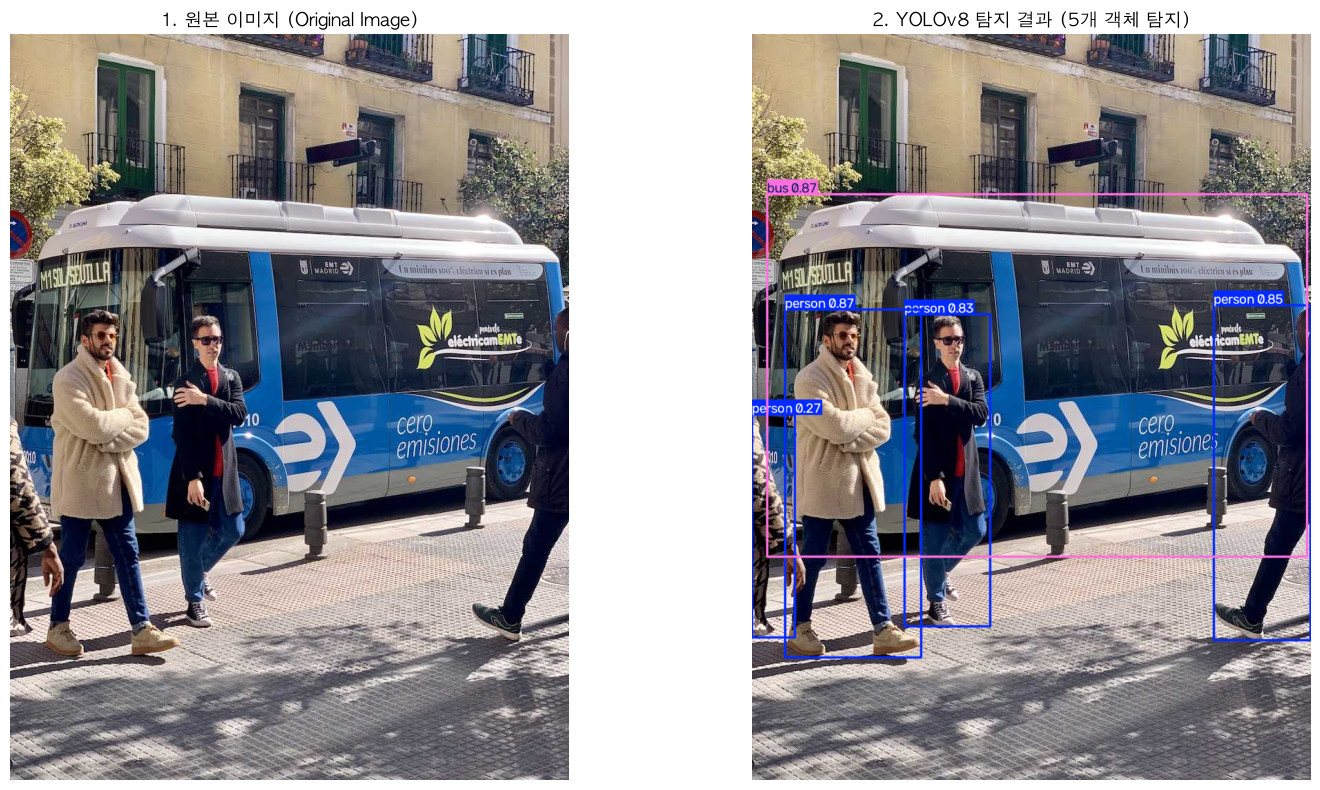

In [2]:
# Ultralytics 패키지에서 YOLO 객체 탐지 모델 클래스 불러오기
from ultralytics import YOLO

# 컴퓨터 비전 및 이미지 처리용 OpenCV 라이브러리 불러오기
import cv2

# 수치 계산 및 배열 처리를 위한 NumPy 라이브러리 불러오기
import numpy as np

# 데이터 시각화를 위한 Matplotlib 라이브러리 불러오기
import matplotlib.pyplot as plt

# 파일 및 디렉토리 경로 처리를 위한 Path 클래스 불러오기
from pathlib import Path

# PyTorch 라이브러리 불러오기
import torch

# URL 요청 시 403 Forbidden 오류 방지를 위한 모듈 불러오기
import urllib.request

import matplotlib.pyplot as plt
import platform

# 1. OS별 한글 폰트 설정
if platform.system() == 'Darwin': # Mac 환경
    plt.rc('font', family='AppleGothic')
elif platform.system() == 'Windows': # Windows 환경
    plt.rc('font', family='Malgun Gothic')
else: # Linux 환경 (Colab 등)
    plt.rc('font', family='NanumGothic')

# 2. 마이너스(-) 기호 깨짐 방지 설정
plt.rcParams['axes.unicode_minus'] = False


# GPU(CUDA) 사용 가능 여부를 확인하여 연산 장치(device)를 'cuda' 또는 'cpu'로 설정
device = "cuda" if torch.cuda.is_available() else "cpu"

# 사전 학습된 YOLOv8 Nano 모델 로드
model = YOLO("yolov8n.pt")

# 이미지 URL 정의
img_url = "https://ultralytics.com/images/bus.jpg"

# --- 단일 이미지 추론 --------------------
results = model.predict(
    source=img_url,  # 추론할 이미지 경로 (URL 사용 가능)
    conf=0.25,       # 신뢰도(Confidence) 임계값 (0.25 이상만 탐지)
    iou=0.45,        # NMS 적용을 위한 IoU 임계값
    imgsz=640,       # 입력 이미지 재조정(Resize) 크기
    device=device,   # 추론에 사용할 연산 장치
    verbose=False,   # 상세 로그 출력 여부 (비활성화)
)

# 단일 이미지 추론 결과 객체 추출
result = results[0]

# --- 추론 결과 상세 출력 --------------------
print("=== 추론 결과 상세 ===")
print(f"원본 이미지 크기: {result.orig_shape}")  # (H, W)
print(f"탐지 박스 수    : {len(result.boxes)}")

if len(result.boxes) > 0:
    print("\n[탐지된 객체 목록]")
    print(f"{'클래스':<15} {'신뢰도':>8} {'x1':>6} {'y1':>6} {'x2':>6} {'y2':>6}")
    print("-" * 55)

    for box in result.boxes:
        cls_id = int(box.cls[0])
        cls_name = model.names[cls_id]
        conf_val = float(box.conf[0])
        x1, y1, x2, y2 = [int(v) for v in box.xyxy[0]]
        print(f"{cls_name:<15} {conf_val:>8.3f} {x1:>6} {y1:>6} {x2:>6} {y2:>6}")

# --- 원본 이미지 안전 다운로드 (403 Forbidden 오류 방지) ---
# 일반 웹 브라우저 접속으로 위장하기 위한 User-Agent 헤더 추가
req = urllib.request.Request(img_url, headers={'User-Agent': 'Mozilla/5.0'})

# 이미지 데이터 로드 및 OpenCV 이미지 형식으로 디코딩
with urllib.request.urlopen(req) as response:
    arr = np.asarray(bytearray(response.read()), dtype=np.uint8)
    orig_img = cv2.imdecode(arr, cv2.IMREAD_COLOR)

# --- 결과 시각화 이미지 생성 --------------------
vis_img = result.plot(
    conf=True,      # 바운딩 박스 위에 신뢰도 점수 표시
    labels=True,    # 바운딩 박스 위에 클래스 레이블 표시
    boxes=True,     # 바운딩 박스 사각형 그리기
    line_width=2,   # 바운딩 박스 선 두께
    font_size=12,   # 텍스트 폰트 크기
)

# --- Matplotlib을 활용한 원본 vs 탐지 결과 비교 출력 ---
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# [좌측] 원본 이미지 출력 (BGR -> RGB)
axes[0].imshow(cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB))
axes[0].set_title("1. 원본 이미지 (Original Image)", fontsize=13, fontweight='bold')
axes[0].axis("off")

# [우측] 탐지 결과 이미지 출력 (BGR -> RGB)
axes[1].imshow(cv2.cvtColor(vis_img, cv2.COLOR_BGR2RGB))
axes[1].set_title(f"2. YOLOv8 탐지 결과 ({len(result.boxes)}개 객체 탐지)", fontsize=13, fontweight='bold')
axes[1].axis("off")

plt.tight_layout()
plt.savefig("yolo_comparison_result.png", dpi=150, bbox_inches="tight")
plt.show()

이미지/비디오 탐지

Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
=== 추론 결과 상세 ===
원본 이미지 크기: (1080, 810)
탐지 박스 수    : 5

[탐지된 객체 목록]
클래스                  신뢰도     x1     y1     x2     y2
-------------------------------------------------------
bus                0.873     22    231    804    756
person             0.865     48    398    245    902
person             0.854    669    392    809    877
person             0.825    221    405    345    857
person             0.267      0    550     62    873


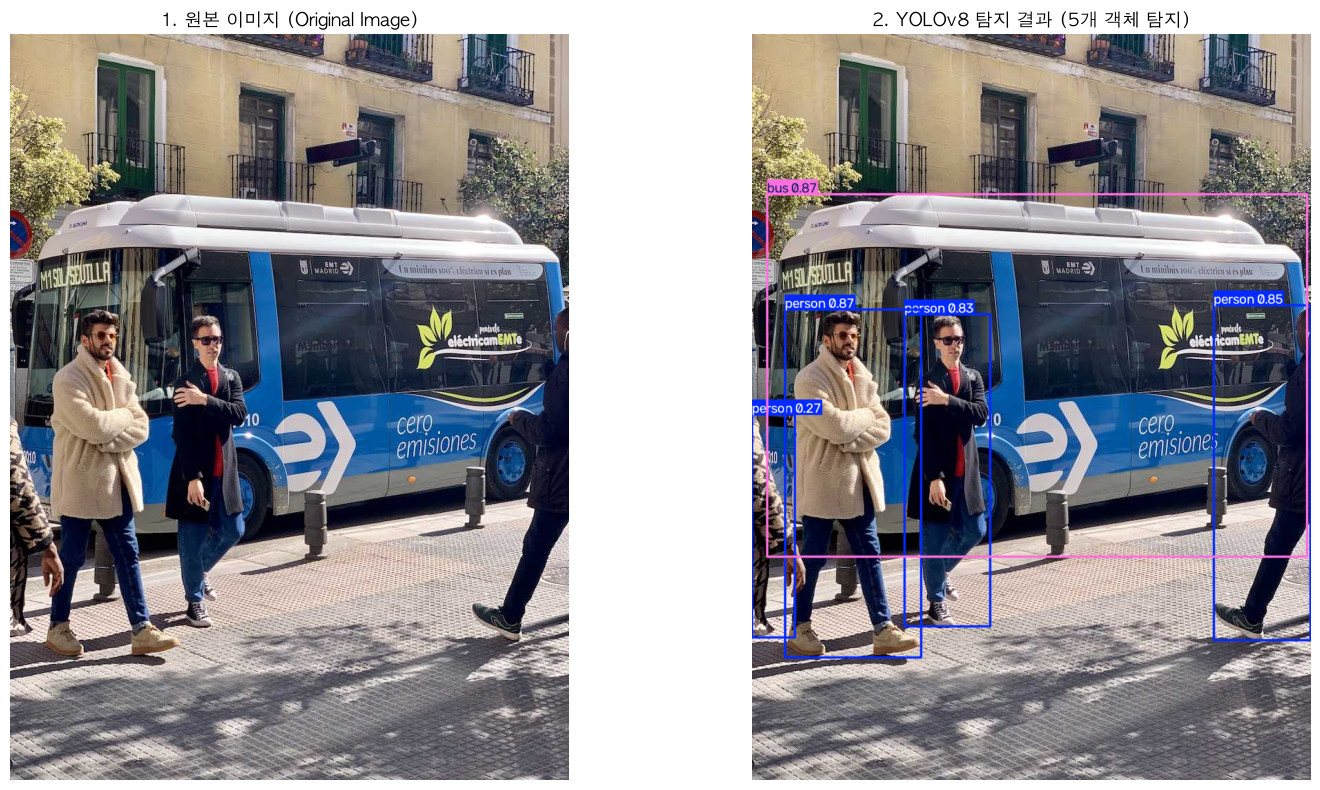

In [3]:
# Ultralytics 패키지에서 YOLO 객체 탐지 모델 클래스 불러오기
from ultralytics import YOLO

# 컴퓨터 비전 및 이미지 처리용 OpenCV 라이브러리 불러오기
import cv2

# 수치 계산 및 배열 처리를 위한 NumPy 라이브러리 불러오기
import numpy as np

# 데이터 시각화를 위한 Matplotlib 라이브러리 불러오기
import matplotlib.pyplot as plt

# 파일 및 디렉토리 경로 처리를 위한 Path 클래스 불러오기
from pathlib import Path

# PyTorch 라이브러리 불러오기
import torch

# URL 요청 시 403 Forbidden 오류 방지를 위한 모듈 불러오기
import urllib.request

import matplotlib.pyplot as plt
import platform

# 1. OS별 한글 폰트 설정
if platform.system() == 'Darwin': # Mac 환경
    plt.rc('font', family='AppleGothic')
elif platform.system() == 'Windows': # Windows 환경
    plt.rc('font', family='Malgun Gothic')
else: # Linux 환경 (Colab 등)
    plt.rc('font', family='NanumGothic')

# 2. 마이너스(-) 기호 깨짐 방지 설정
plt.rcParams['axes.unicode_minus'] = False


# GPU(CUDA) 사용 가능 여부를 확인하여 연산 장치(device)를 'cuda' 또는 'cpu'로 설정
device = "cuda" if torch.cuda.is_available() else "cpu"

# 사전 학습된 YOLOv8 Nano 모델 로드
model = YOLO("yolov8n.pt")

# 이미지 URL 정의
img_url = "https://ultralytics.com/images/bus.jpg"

# --- 단일 이미지 추론 --------------------
results = model.predict(
    source=img_url,  # 추론할 이미지 경로 (URL 사용 가능)
    conf=0.25,       # 신뢰도(Confidence) 임계값 (0.25 이상만 탐지)
    iou=0.45,        # NMS 적용을 위한 IoU 임계값
    imgsz=640,       # 입력 이미지 재조정(Resize) 크기
    device=device,   # 추론에 사용할 연산 장치
    verbose=False,   # 상세 로그 출력 여부 (비활성화)
)

# 단일 이미지 추론 결과 객체 추출
result = results[0]

# --- 추론 결과 상세 출력 --------------------
print("=== 추론 결과 상세 ===")
print(f"원본 이미지 크기: {result.orig_shape}")  # (H, W)
print(f"탐지 박스 수    : {len(result.boxes)}")

if len(result.boxes) > 0:
    print("\n[탐지된 객체 목록]")
    print(f"{'클래스':<15} {'신뢰도':>8} {'x1':>6} {'y1':>6} {'x2':>6} {'y2':>6}")
    print("-" * 55)

    for box in result.boxes:
        cls_id = int(box.cls[0])
        cls_name = model.names[cls_id]
        conf_val = float(box.conf[0])
        x1, y1, x2, y2 = [int(v) for v in box.xyxy[0]]
        print(f"{cls_name:<15} {conf_val:>8.3f} {x1:>6} {y1:>6} {x2:>6} {y2:>6}")

# --- 원본 이미지 안전 다운로드 (403 Forbidden 오류 방지) ---
# 일반 웹 브라우저 접속으로 위장하기 위한 User-Agent 헤더 추가
req = urllib.request.Request(img_url, headers={'User-Agent': 'Mozilla/5.0'})

# 이미지 데이터 로드 및 OpenCV 이미지 형식으로 디코딩
with urllib.request.urlopen(req) as response:
    arr = np.asarray(bytearray(response.read()), dtype=np.uint8)
    orig_img = cv2.imdecode(arr, cv2.IMREAD_COLOR)

# --- 결과 시각화 이미지 생성 --------------------
vis_img = result.plot(
    conf=True,      # 바운딩 박스 위에 신뢰도 점수 표시
    labels=True,    # 바운딩 박스 위에 클래스 레이블 표시
    boxes=True,     # 바운딩 박스 사각형 그리기
    line_width=2,   # 바운딩 박스 선 두께
    font_size=12,   # 텍스트 폰트 크기
)

# --- Matplotlib을 활용한 원본 vs 탐지 결과 비교 출력 ---
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# [좌측] 원본 이미지 출력 (BGR -> RGB)
axes[0].imshow(cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB))
axes[0].set_title("1. 원본 이미지 (Original Image)", fontsize=13, fontweight='bold')
axes[0].axis("off")

# [우측] 탐지 결과 이미지 출력 (BGR -> RGB)
axes[1].imshow(cv2.cvtColor(vis_img, cv2.COLOR_BGR2RGB))
axes[1].set_title(f"2. YOLOv8 탐지 결과 ({len(result.boxes)}개 객체 탐지)", fontsize=13, fontweight='bold')
axes[1].axis("off")

plt.tight_layout()
plt.savefig("yolo_comparison_result.png", dpi=150, bbox_inches="tight")
plt.show()

바운딩 박스 상세 분석 및 통계

=== 탐지 결과 DataFrame ===
  class_name  confidence          x1          y1           x2          y2           area
0     person    0.835720  114.186737  197.448547  1114.545898  711.877319  514613.519220
1     person    0.819107  748.313110   41.785461  1142.019653  713.063049  264286.378501
2        tie    0.289377  439.762268  437.147339   524.260010  709.224976   22989.945870

=== 탐지 통계 ===
총 탐지 수 : 3
클래스 분포 : {'person': 2, 'tie': 1}
평균 신뢰도 : 0.648
최소 신뢰도 : 0.289
최대 신뢰도 : 0.836
평균 면적비 : 29.00%


findfont: Failed to find font weight bold, now using 400.


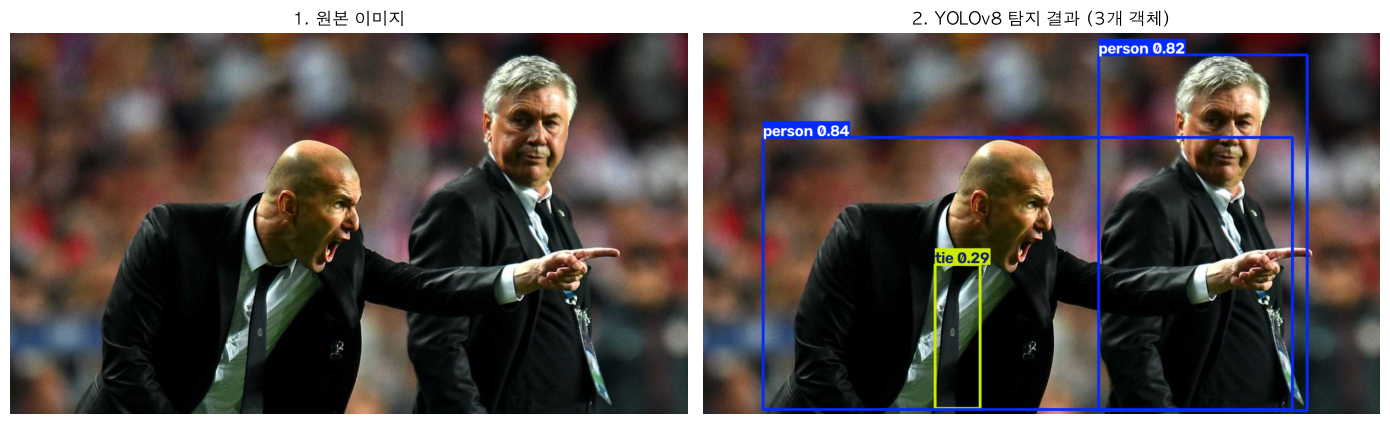

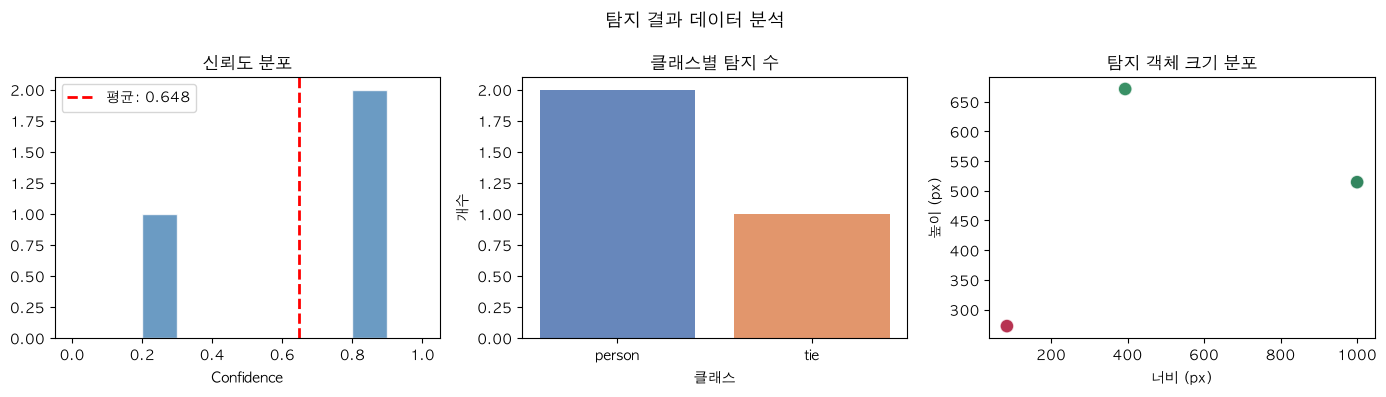

In [4]:

# Ultralytics 패키지에서 YOLO 모델 클래스 불러오기
from ultralytics import YOLO

# 수치 연산을 위한 NumPy 라이브러리 불러오기
import numpy as np

# 데이터 분석 및 테이블 구조 처리를 위한 Pandas 라이브러리 불러오기
import pandas as pd

# 데이터 시각화를 위한 Matplotlib 라이브러리 불러오기
import matplotlib.pyplot as plt

# 시각화 스타일 및 색상 팔레트 사용을 위한 Seaborn 라이브러리 불러오기
import seaborn as sns

# 이미지 처리용 OpenCV 라이브러리 불러오기
import cv2

# OS 판단 및 URL 요청용 모듈 불러오기
import platform
import urllib.request

# --- Matplotlib 한글 폰트 및 마이너스 깨짐 방지 설정 --------------------
if platform.system() == 'Darwin':       # Mac OS
    plt.rc('font', family='AppleGothic')
elif platform.system() == 'Windows':   # Windows OS
    plt.rc('font', family='Malgun Gothic')
else:                                  # Linux / Colab 등
    plt.rc('font', family='NanumGothic')

plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

# 사전 학습된 YOLOv8 Nano 모델 로드
model = YOLO("yolov8n.pt")

# 추론 대상 이미지 URL
img_url = "https://ultralytics.com/images/zidane.jpg"

# --- 단일 이미지 추론 --------------------
results = model.predict(
    source=img_url,  
    conf=0.25,        # 신뢰도(Confidence) 임계값 (0.25 이상만 탐지)
    verbose=False,    # 추론 진행 상황 출력 비활성화
)

# 단일 이미지 추론 결과 추출
result = results[0]


# --- 탐지 결과를 DataFrame으로 변환 --------------------
def results_to_dataframe(result, model):
    """YOLO 결과를 pandas DataFrame으로 변환"""
    rows = []
    h, w = result.orig_shape

    for box in result.boxes:
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        cx, cy, bw, bh = box.xywh[0].tolist()

        rows.append({
            "class_id": int(box.cls[0]),
            "class_name": model.names[int(box.cls[0])],
            "confidence": float(box.conf[0]),
            "x1": x1,
            "y1": y1,
            "x2": x2,
            "y2": y2,
            "cx": cx,
            "cy": cy,
            "width": bw,
            "height": bh,
            "area": bw * bh,
            "area_ratio": (bw * bh) / (w * h),
            "aspect_ratio": bw / (bh + 1e-8),  # ZeroDivision 방지용 1e-8 추가
        })

    return pd.DataFrame(rows)


# 탐지 결과 DataFrame 생성
df_det = results_to_dataframe(result, model)

# 탐지된 객체가 존재할 경우 통계 출력 및 시각화 진행
if len(df_det) > 0:
    # 1. 터미널 결과 및 수치 통계 출력
    print("=== 탐지 결과 DataFrame ===")
    print(df_det[["class_name", "confidence", "x1", "y1", "x2", "y2", "area"]].to_string())

    print("\n=== 탐지 통계 ===")
    print(f"총 탐지 수 : {len(df_det)}")
    print(f'클래스 분포 : {df_det["class_name"].value_counts().to_dict()}')
    print(f'평균 신뢰도 : {df_det["confidence"].mean():.3f}')
    print(f'최소 신뢰도 : {df_det["confidence"].min():.3f}')
    print(f'최대 신뢰도 : {df_det["confidence"].max():.3f}')
    print(f'평균 면적비 : {df_det["area_ratio"].mean()*100:.2f}%')

    # 2. 이미지 비교 시각화 (원본 vs 탐지 결과)
    req = urllib.request.Request(img_url, headers={'User-Agent': 'Mozilla/5.0'})
    with urllib.request.urlopen(req) as response:
        arr = np.asarray(bytearray(response.read()), dtype=np.uint8)
        orig_img = cv2.imdecode(arr, cv2.IMREAD_COLOR)

    vis_img = result.plot()  # 바운딩 박스 그려진 이미지 생성

    fig_img, axes_img = plt.subplots(1, 2, figsize=(14, 6))

    # [좌측] 원본 이미지
    axes_img[0].imshow(cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB))
    axes_img[0].set_title("1. 원본 이미지", fontsize=12, fontweight="bold")
    axes_img[0].axis("off")

    # [우측] 탐지 결과 이미지
    axes_img[1].imshow(cv2.cvtColor(vis_img, cv2.COLOR_BGR2RGB))
    axes_img[1].set_title(f"2. YOLOv8 탐지 결과 ({len(df_det)}개 객체)", fontsize=12, fontweight="bold")
    axes_img[1].axis("off")

    plt.tight_layout()
    plt.savefig("image_detection_result.png", dpi=150, bbox_inches="tight")
    plt.show()

    # 3. 데이터 통계 시각화 (3단 캔버스 서브플롯)
    fig_stat, axes_stat = plt.subplots(1, 3, figsize=(14, 4))
    fig_stat.suptitle("탐지 결과 데이터 분석", fontsize=13, fontweight="bold")

    # (1) 신뢰도 분포 히스토그램
    axes_stat[0].hist(
        df_det["confidence"],
        bins=10,
        range=(0, 1),
        color="steelblue",
        alpha=0.8,
        edgecolor="white",
    )
    axes_stat[0].axvline(
        df_det["confidence"].mean(),
        color="red",
        lw=2,
        ls="--",
        label=f'평균: {df_det["confidence"].mean():.3f}',
    )
    axes_stat[0].set_title("신뢰도 분포")
    axes_stat[0].set_xlabel("Confidence")
    axes_stat[0].legend()

    # (2) 클래스별 탐지 수 막대그래프
    cls_cnt = df_det["class_name"].value_counts()
    axes_stat[1].bar(
        cls_cnt.index,
        cls_cnt.values,
        color=sns.color_palette("deep", len(cls_cnt)),
        alpha=0.85,
    )
    axes_stat[1].set_title("클래스별 탐지 수")
    axes_stat[1].set_xlabel("클래스")
    axes_stat[1].set_ylabel("개수")

    # (3) 면적 및 크기 분포 산점도
    axes_stat[2].scatter(
        df_det["width"],
        df_det["height"],
        c=df_det["confidence"],
        cmap="RdYlGn",
        s=100,
        alpha=0.8,
        edgecolors="white",
    )
    axes_stat[2].set_title("탐지 객체 크기 분포")
    axes_stat[2].set_xlabel("너비 (px)")
    axes_stat[2].set_ylabel("높이 (px)")

    plt.tight_layout()
    plt.savefig("detection_analysis.png", dpi=150, bbox_inches="tight")
    plt.show()

else:
    print("탐지된 객체가 없습니다.")

신뢰도 임계값과 정밀도-재현율

Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
conf=0.10:  6개 탐지 | 평균 신뢰도: 0.655
Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
conf=0.25:  5개 탐지 | 평균 신뢰도: 0.737
Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
conf=0.40:  4개 탐지 | 평균 신뢰도: 0.854
Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
conf=0.50:  4개 탐지 | 평균 신뢰도: 0.854
Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
conf=0.60:  4개 탐지 | 평균 신뢰도: 0.854
Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
conf=0.75:  4개 탐지 | 평균 신뢰도: 0.854
Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
conf=0.90:  0개 탐지 | 평균 신뢰도: 0.000
Found https://ultralytics.com/images/bus.jpg locally at bus.jpg


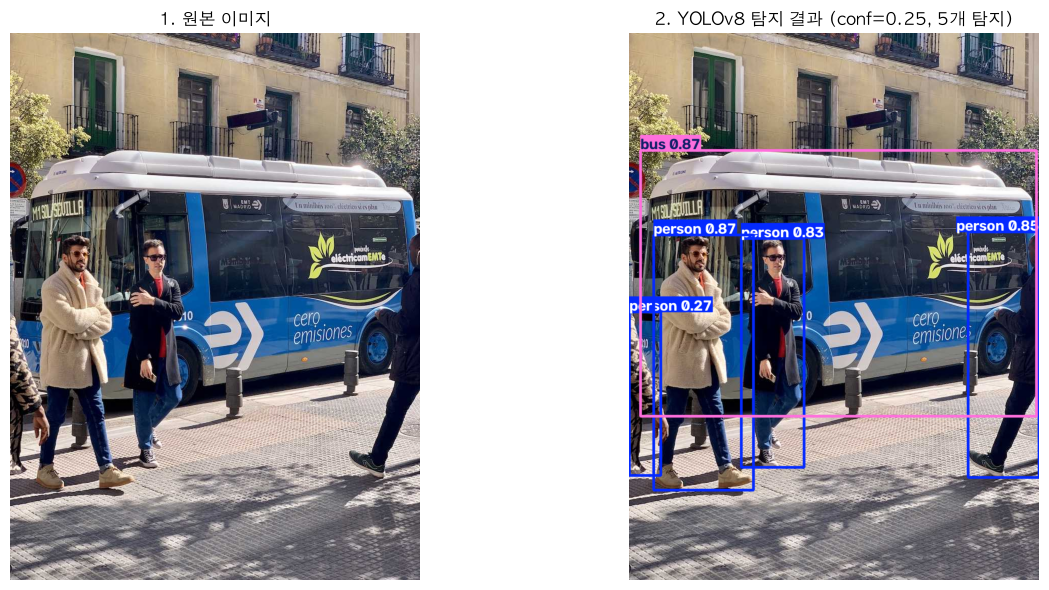

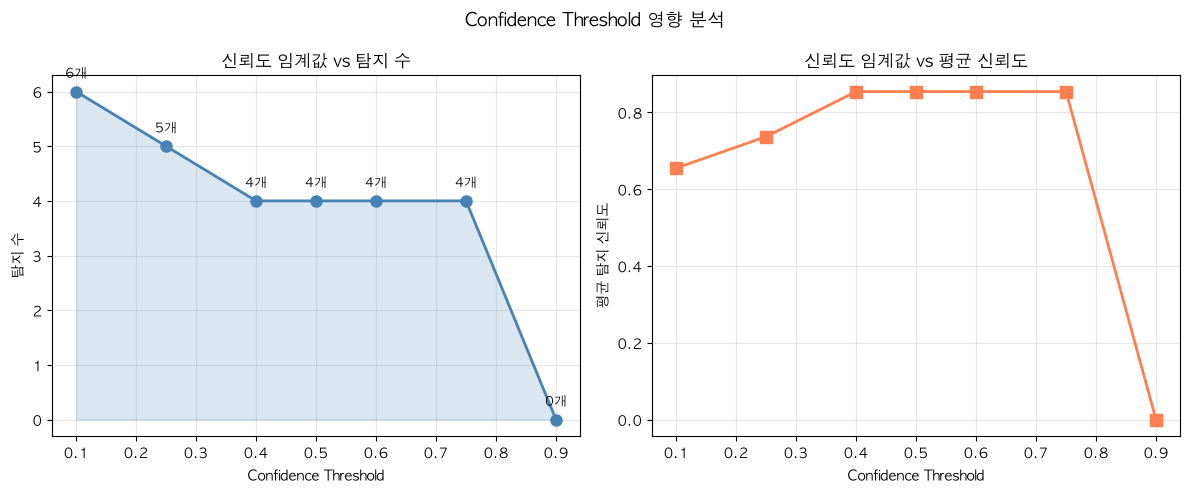


=== 객체 탐지 성능 지표 ===
  Precision (정밀도)     : TP / (TP + FP) - 탐지한 것 중 실제 정답 비율
  Recall (재현율)        : TP / (TP + FN) - 실제 정답 중 탐지한 비율
  mAP@50              : IoU=0.5 기준 평균 정밀도 (Average Precision)의 평균
  mAP@50-95           : IoU=0.5~0.95의 10단계 mAP 평균 (COCO 표준)
  F1-Score            : 2 * Precision * Recall / (Precision + Recall)


In [5]:
# Ultralytics 패키지에서 YOLO 모델 클래스 불러오기
from ultralytics import YOLO

# 수치 계산을 위한 NumPy 라이브러리 불러오기
import numpy as np

# 데이터 시각화를 위한 Matplotlib 라이브러리 불러오기
import matplotlib.pyplot as plt

# 이미지 처리를 위한 OpenCV 및 환경 판단/URL 로드용 모듈 불러오기
import cv2
import platform
import urllib.request

# --- Matplotlib 한글 폰트 및 마이너스 깨짐 방지 설정 --------------------
if platform.system() == "Darwin":  # Mac OS
    plt.rc("font", family="AppleGothic")
elif platform.system() == "Windows":  # Windows OS
    plt.rc("font", family="Malgun Gothic")
else:  # Linux / Colab 등
    plt.rc("font", family="NanumGothic")

plt.rcParams["axes.unicode_minus"] = False  # 마이너스 기호 깨짐 방지

# 사전 학습된 YOLOv8 Nano 모델 로드
model = YOLO("yolov8n.pt")

# 테스트에 사용할 이미지 URL 설정
test_url = "https://ultralytics.com/images/bus.jpg"

# --- 다양한 신뢰도 임계값으로 추론 결과 비교 --------------------
conf_thresholds = [0.1, 0.25, 0.4, 0.5, 0.6, 0.75, 0.9]
conf_results = {}

for conf in conf_thresholds:
    r = model.predict(test_url, conf=conf, verbose=False)[0]

    conf_results[conf] = {
        "n_det": len(r.boxes),
        "mean_conf": float(r.boxes.conf.mean()) if len(r.boxes) > 0 else 0,
        "classes": [model.names[int(c)] for c in r.boxes.cls]
        if len(r.boxes) > 0
        else [],
    }

    print(
        f'conf={conf:.2f}: {conf_results[conf]["n_det"]:2d}개 탐지 | '
        f'평균 신뢰도: {conf_results[conf]["mean_conf"]:.3f}'
    )

# --- 1. 객체 탐지 이미지 비교 출력 (원본 vs 기준 Threshold 0.25 결과) ---
# 403 Forbidden 오류 방지를 위해 User-Agent 설정 후 원본 이미지 로드
req = urllib.request.Request(test_url, headers={"User-Agent": "Mozilla/5.0"})
with urllib.request.urlopen(req) as response:
    arr = np.asarray(bytearray(response.read()), dtype=np.uint8)
    orig_img = cv2.imdecode(arr, cv2.IMREAD_COLOR)

# 기준 신뢰도(0.25)로 기본 탐지 결과 이미지 생성
default_result = model.predict(test_url, conf=0.25, verbose=False)[0]
vis_img = default_result.plot()

fig_img, axes_img = plt.subplots(1, 2, figsize=(14, 6))

# [좌측] 원본 이미지
axes_img[0].imshow(cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB))
axes_img[0].set_title("1. 원본 이미지", fontsize=12, fontweight="bold")
axes_img[0].axis("off")

# [우측] 탐지 결과 이미지 (conf=0.25)
axes_img[1].imshow(cv2.cvtColor(vis_img, cv2.COLOR_BGR2RGB))
axes_img[1].set_title(
    f"2. YOLOv8 탐지 결과 (conf=0.25, {len(default_result.boxes)}개 탐지)",
    fontsize=12,
    fontweight="bold",
)
axes_img[1].axis("off")

plt.tight_layout()
plt.savefig("detection_vis_result.png", dpi=150, bbox_inches="tight")
plt.show()

# --- 2. 임계값 vs 탐지 수/평균 신뢰도 분석 그래프 --------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

confs = list(conf_results.keys())
n_dets = [conf_results[c]["n_det"] for c in confs]
m_conf = [conf_results[c]["mean_conf"] for c in confs]

# (1) 신뢰도 임계값 vs 탐지 수
axes[0].plot(confs, n_dets, "o-", color="steelblue", lw=2, ms=8)
axes[0].fill_between(confs, n_dets, alpha=0.2, color="steelblue")
axes[0].set_title("신뢰도 임계값 vs 탐지 수", fontweight="bold")
axes[0].set_xlabel("Confidence Threshold")
axes[0].set_ylabel("탐지 수")
axes[0].grid(True, alpha=0.3)

for x, y in zip(confs, n_dets):
    axes[0].annotate(
        f"{y}개",
        (x, y),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center",
        fontsize=9,
    )

# (2) 신뢰도 임계값 vs 평균 신뢰도
axes[1].plot(confs, m_conf, "s-", color="coral", lw=2, ms=8)
axes[1].set_title("신뢰도 임계값 vs 평균 신뢰도", fontweight="bold")
axes[1].set_xlabel("Confidence Threshold")
axes[1].set_ylabel("평균 탐지 신뢰도")
axes[1].grid(True, alpha=0.3)

plt.suptitle("Confidence Threshold 영향 분석", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("conf_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

# --- 성능 평가 지표 설명 --------------------
print("\n=== 객체 탐지 성능 지표 ===")
metrics = {
    "Precision (정밀도)": "TP / (TP + FP) - 탐지한 것 중 실제 정답 비율",
    "Recall (재현율)": "TP / (TP + FN) - 실제 정답 중 탐지한 비율",
    "mAP@50": "IoU=0.5 기준 평균 정밀도 (Average Precision)의 평균",
    "mAP@50-95": "IoU=0.5~0.95의 10단계 mAP 평균 (COCO 표준)",
    "F1-Score": "2 * Precision * Recall / (Precision + Recall)",
}

for metric, desc in metrics.items():
    print(f"  {metric:<20}: {desc}")